# FTNODE / Duffing — items 1, 2, 3

Self-contained. Plant, models, training, diagnostics. Set `SMOKE=True` for a ~1 min sanity pass;
`QUICK=True` (default) is a few minutes per model on CPU; `QUICK=False` restores the original
settings (`L=200, L_eval=600, n_traj=512, epochs=200`).

---

### Item 1 — make $A$ constant

The split $F=A(z)\,(z-g(z,u))$ carries a gauge group $\mathcal G=C^1(D;GL(m))$: for **any** nonsingular
field $A$, setting $g:=z-A^{-1}F$ reproduces $F$ exactly. So *"$A$ learns transients, $g$ learns
equilibria"* is a gauge choice, not a property of the architecture. Gauge-invariant: the root set
$\{z=g(z,u)\}=\{F=0\}$ and $J_F$ everywhere. Gauge-dependent: $A$, $\operatorname{spec}A$, $\partial_zg$ off the root set.

Fixing $A$ constant fixes the gauge completely ($g=z-A^{-1}F$ is then unique given $F$), keeps the
class universal, and buys three things:

1. **Exact Jacobian.** $J_F(z)=A\,(I-\partial_zg(z,u))$, with no $C_{ij}=\sum_k(\partial_jA_{ik})(z_k-g_k)$ term.
2. **Forward invariance is recovered.** See below.
3. **A closed-form $k$-contraction criterion** in terms of $\partial_zg$ alone.

### Forward invariance: reconciling with `foundation.tex`

`foundation.tex` Thm 1 (`thm:invariance`) gives forward invariance of $\Omega=\bar B(x_0,R)$,
$R=\kappa\,r_{\rm in}$, $\kappa=\sigma_{\max}/\sigma_{\min}$. Taking $x_0=0$ and
$\operatorname{im}(g)\subseteq[-R_g,R_g]^m$ gives $r_{\rm in}=R_g\sqrt m$ and

$$R_{\rm ball} \;=\; \frac{\|A\|_2\,R_g\sqrt m}{\sigma_{\min}}.$$

Two caveats that matter here:

* **Assumption 2 (`ass:contraction`) asks for $A(x)$ symmetric** negative definite. The model's
  $A=-(LL^\top+\sigma_{\min}I)+(M-M^\top)$ is not symmetric. The proof does not need symmetry — the
  radial term needs $\lambda_{\max}(\operatorname{sym}A)\le-\sigma_{\min}$ and the cross term needs
  $\|A\|_2\le\sigma_{\max}$ — but these are then *two separate* hypotheses, and only the first is
  enforced by construction. `cor:diagonal` is the elementwise case, where they coincide.
* **$\sigma_{\max}<\infty$ is the binding hypothesis.** For a state-dependent MLP $A(z)$, SiLU layers
  grow linearly so $\|A(z)\|_2=O(\|z\|^2)$ and $\sigma_{\max}=\infty$: Thm 1 has no content.
  Concretely, $\operatorname{sym}A\preceq-\sigma_{\min}I$ plus bounded $g$ does **not** imply bounded $z$:
  take $A(z)=-\epsilon I-\|z\|^2J$, $g(z)=-\rho Jz/\|z\|$ with $J$ the planar rotation generator; then
  $\tfrac{d}{dt}\tfrac12\|z\|^2=-\epsilon\|z\|^2+\rho\|z\|^3$ and no ball of radius $>\epsilon/\rho$
  is invariant. Making $A$ constant supplies $\sigma_{\max}=\|A\|_2$ and the theorem applies.

### Item 2 — the actual contraction diagnostic

The original notebook plots $\operatorname{spec}A(z)$. $A$ is **not** the Jacobian. We compute $J_\theta$ exactly and report

$$\mathrm{KF}_k(z):=\sum_{i=1}^{k}\lambda_i\big(\operatorname{sym}J_\theta\big),
\qquad
s_k(z):=\max_{i_1<\cdots<i_k}\operatorname{Re}\big(\lambda_{i_1}+\cdots+\lambda_{i_k}\big).$$

Since $A\mapsto A^{[k]}$ is linear and commutes with transposition, $\operatorname{sym}(A^{[k]})=(\operatorname{sym}A)^{[k]}$,
and the $k$-additive compound of a symmetric matrix has spectrum equal to the $k$-subset sums. Hence
$\mathrm{KF}_k=\mu_2(J^{[k]})$ — **no compound matrix is ever built**, cost $O(m^3)$. And $s_k$ is the spectral
abscissa of $J^{[k]}$. On a **forward-invariant** set $D$:

| condition | conclusion |
|---|---|
| $\mathrm{KF}_2<0$ on $D$ | **sufficient**: 2-contractive w.r.t. $P=I$ |
| $s_2>0$ somewhere in $D$ | **falsifies** 2-contraction for *every* constant $P$ (as $\operatorname{Re}\lambda\le\mu_P$) |
| $s_2<0<\mathrm{KF}_2$ | inconclusive at $P=I$; a weighted $P$ may work |

$\lambda_1(\operatorname{sym}J)>0$ is *expected*, not a failure — it is what multistability requires. And
$\operatorname{tr}J\equiv-\delta$ holds for the **plant** ($d=2$); for the $m=4$ latent
$\operatorname{tr}J_\theta=-\delta+\operatorname{tr}J_{\rm transverse}$, so do not expect a Dirac.

We probe three sets: **rollout** (reachable), **box** $[-R_z,R_z]^m$ (neither invariant nor reachable —
the rollout leaves it), and **ball** of radius $R_{\rm ball}$ (the only set on which the theorems have a
hypothesis; exists for constant $A$ only).

### Item 3 — transverse-rate test at the saddle

At an equilibrium the linearization is invariant under smooth conjugacy, so two of the four eigenvalues
of $J_\theta(z^*)$ must equal the plant's: $\{0.905,-1.105\}$ at the saddle, $\{-0.1\pm1.41i\}$ at the
sinks ($u=0$, $\delta=0.2$). The other $m-2$ are transverse rates $\tau_j$. 2-contraction at $z^*$ needs
$\lambda_1+\tau_j<0$ for every $j$, i.e. $\tau_j<-0.905$ at the saddle.

Two `foundation.tex` quantities come free from $\partial_zg(z^*)$ and are reported alongside:
$\lambda_{\max}(\operatorname{sym}J_g)$ from `thm:hurwitz-sym`, and $\|\partial_zg\|_2$ from `prop:hierarchy`.
**`eq:sym-cond` must fail at the saddle** — the equilibrium is unstable, so $J$ is not Hurwitz and
$\lambda_{\max}(\operatorname{sym}J_g)\ge1$ necessarily. That is exactly why $k=2$ is the right order.

*Free byproduct.* Since $g_\theta(D)\subseteq D$ with $D$ star-shaped about $0$, Brouwer degree forces
$\sum_{z^*}\operatorname{sign}\det(I-\partial_zg_\theta(z^*))=1$. A bug detector, and the discrete analogue of the
Poincaré-index argument in arXiv:2502.14242.


In [1]:
from __future__ import annotations
import time, pathlib
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as Fnn
from torch.func import jacrev, vmap
from scipy.optimize import root as scipy_root

torch.set_num_threads(4)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================ configuration ============================
SMOKE          = False   # tiny end-to-end sanity pass (~1 min); overrides QUICK
QUICK          = False    # False -> original settings (L=200, L_eval=600, 512 traj, 200 epochs)
REUSE_CKPT     = True    # load ckpt-*.pth if present instead of retraining
TRAIN_BASELINE = True    # also train the state-dependent-A model, for comparison

SIGMA_LIST = [0.1, 1.2]  # sigma_min for the constant-A model.  0.905 = lambda_1 at the plant saddle.

LAMBDA_RES = 0.0
# NOTE: default OFF (original notebook used 1e-2).  The residual penalty is a gauge-fixing term
# aimed at the degenerate end of the orbit (g -> z, ||A|| -> inf).  It inflates ||A||_2, which is
# exactly sigma_max in foundation.tex Thm 1, so it enlarges R_ball.  Set 1e-2 to A/B it.

h_dt     = 0.05          # integration timestep
tau      = 8             # encoder window
m        = 4             # latent dim (plant is d = 2)
R_LATENT = 2.0           # z_scale = R_g
u_range  = 0.25
x_range  = 1.6

if SMOKE:
    L, L_eval, N_TRAIN, N_VAL, EPOCHS = 40,  60, 48, 12,  4
    N_BOX = N_ROLL = 300; N_STARTS = 60
elif QUICK:
    L, L_eval, N_TRAIN, N_VAL, EPOCHS = 150, 300, 256, 32, 60
    N_BOX = N_ROLL = 4000; N_STARTS = 400
else:
    L, L_eval, N_TRAIN, N_VAL, EPOCHS = 200, 600, 512, 64, 200
    N_BOX = N_ROLL = 8000; N_STARTS = 800

SEED = 0
TAG  = 'smoke' if SMOKE else ('quick' if QUICK else 'full')   # checkpoints are tagged by config,
                                                              # so a SMOKE run can never be reused
torch.manual_seed(SEED); np.random.seed(SEED)
print(f'device={device}  SMOKE={SMOKE}  QUICK={QUICK}  tag={TAG}  L={L}  L_eval={L_eval}  '
      f'n_traj={N_TRAIN}  epochs={EPOCHS}  lambda_res={LAMBDA_RES}')

device=cpu  SMOKE=False  QUICK=False  tag=full  L=200  L_eval=600  n_traj=512  epochs=200  lambda_res=0.0


## 0. Plant

$\dot q_1=q_2$, $\dot q_2=-\delta q_2+q_1-q_1^3+u$, constant $u$. Autonomous, planar, $\operatorname{tr}J\equiv-\delta$.
For $n=2$, $J^{[2]}=\operatorname{tr}J$: **2-contraction is Bendixson and holds globally, for free.** Every bounded
trajectory converges to an equilibrium. The plant is the easy case; the $m=4$ lift is the object of study.

In [2]:
@dataclass(frozen=True)
class DuffingParams:
    delta: float = 0.2

params = DuffingParams(delta=0.2)

def F_plant(x, u, p=params):
    x1, x2 = x[..., 0], x[..., 1]
    return np.stack([x2, -p.delta * x2 - x1**3 + x1 + np.asarray(u)], axis=-1)

def J_plant(x1, p=params):
    return np.array([[0.0, 1.0], [1.0 - 3.0 * x1**2, -p.delta]])

def equilibria_plant(u):
    r = np.roots([1.0, 0.0, -1.0, -float(u)])
    return [np.array([x.real, 0.0]) for x in sorted(r, key=lambda z: z.real) if abs(x.imag) < 1e-9]

def simulate(x0, u_of_t, p, t_grid):
    xs = np.empty((len(t_grid), 2)); xs[0] = x0
    for i in range(len(t_grid) - 1):
        t = t_grid[i]; h = t_grid[i+1] - t; x = xs[i]
        u1, u2, u4 = u_of_t(t), u_of_t(t + .5*h), u_of_t(t + h)
        k1 = F_plant(x, u1, p); k2 = F_plant(x + .5*h*k1, u2, p)
        k3 = F_plant(x + .5*h*k2, u2, p); k4 = F_plant(x + h*k3, u4, p)
        xs[i+1] = x + (h/6.) * (k1 + 2*k2 + 2*k3 + k4)
    return xs

_q = np.linspace(-x_range, x_range, 4001)
LAM1_PLANT_MAX = max(np.linalg.eigvalsh(.5*(J_plant(q) + J_plant(q).T))[-1] for q in _q)
LAM1_SPEC_SADDLE = float(np.linalg.eigvals(J_plant(0.0)).real.max())

print(f'plant:  tr J = -delta = {-params.delta:+.3f}  everywhere  ->  s_2 = tr J < 0  ->  2-contractive (Bendixson)')
print(f'        max lambda_1(sym J), |q|<={x_range}   = {LAM1_PLANT_MAX:+.4f}   (1-contraction fails everywhere)')
print(f'        spec J at saddle q=0             = {np.round(np.linalg.eigvals(J_plant(0.0)).real, 4)}')
print(f'        spec J at sink   q=1             = {np.round(np.linalg.eigvals(J_plant(1.0)), 4)}')
print(f'\n=> item-3 threshold: transverse rates must satisfy  tau_j < -{LAM1_SPEC_SADDLE:.3f}')

plant:  tr J = -delta = -0.200  everywhere  ->  s_2 = tr J < 0  ->  2-contractive (Bendixson)
        max lambda_1(sym J), |q|<=1.6   = +2.7418   (1-contraction fails everywhere)
        spec J at saddle q=0             = [ 0.905 -1.105]
        spec J at sink   q=1             = [-0.1+1.4107j -0.1-1.4107j]

=> item-3 threshold: transverse rates must satisfy  tau_j < -0.905


In [3]:
def make_dataset(n_traj, L, seed):
    rng = np.random.default_rng(seed)
    Ttot = tau + L + 1
    t_grid = np.arange(Ttot) * h_dt
    Xf = np.zeros((n_traj, Ttot, 2), np.float32); U = np.zeros(n_traj, np.float32)
    for i in range(n_traj):
        x0 = np.array([rng.uniform(-x_range, x_range), rng.uniform(-1.0, 1.0)])
        u  = float(rng.uniform(-u_range, u_range))
        Xf[i] = simulate(x0, lambda t, _u=u: _u, params, t_grid).astype(np.float32); U[i] = u
    Y = Xf[..., 0]                                   # partial observation: q only
    return (torch.from_numpy(Y[:, :tau]), torch.from_numpy(U),
            torch.from_numpy(Y[:, tau:tau+L+1]), torch.from_numpy(Xf[:, tau:tau+L+1]))

t0 = time.time()
Wtr, Utr, Ytr, _ = make_dataset(N_TRAIN, L,      seed=0)
Wva, Uva, Yva, _ = make_dataset(N_VAL,   L_eval, seed=1)
Wtr, Utr, Ytr = Wtr.to(device), Utr.to(device), Ytr.to(device)
Wva, Uva, Yva = Wva.to(device), Uva.to(device), Yva.to(device)
print(f'train {tuple(Ytr.shape)}   val {tuple(Yva.shape)}   ({time.time()-t0:.1f}s)')

train (512, 201)   val (64, 601)   (3.7s)


## 1. Models (item 1)

`LatentFTNODE` reproduces the original exactly (same attribute names, so an existing
`best_model-duffing-lft-residreg.pth` will load). `LatentFTNODEConstA` is item 1: identical `g`,
but $A$ is a constant matrix built from **Parameters**, not networks.

In [4]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=64, depth=3, last_zero=False):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.SiLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)
        if last_zero:
            with torch.no_grad():
                self.net[-1].weight.zero_(); self.net[-1].bias.zero_()
    def forward(self, x): return self.net(x)


class Encoder(nn.Module):
    """phi(window) = z_scale * tanh(MLP(window))  ->  z0 in [-z_scale, z_scale]^m."""
    def __init__(self, tau, m, hidden=64, depth=2, z_scale=2.0):
        super().__init__(); self.net = MLP(tau, m, hidden, depth); self.z_scale = z_scale
    def forward(self, window): return self.z_scale * torch.tanh(self.net(window))


class LinearDecoder(nn.Module):
    def __init__(self, m):
        super().__init__(); self.c = nn.Linear(m, 1, bias=True)
    def forward(self, z): return self.c(z).squeeze(-1)


class LatentFTNODE(nn.Module):
    """BASELINE (original): A(z) = -(L(z)L(z)^T + sigma I) + (M(z) - M(z)^T), state-dependent.

    sym(A) <= -sigma_min I holds by construction.  ||A(z)||_2 is NOT bounded, so
    foundation.tex Thm 1 (which needs sigma_max < inf) does not apply: no invariant set.
    """
    def __init__(self, m=4, q=1, hidden=64, depth=3, sigma_min=0.1, R_g=2.0):
        super().__init__()
        self.m, self.q, self.sigma_min, self.R_g = m, q, sigma_min, R_g
        tril = torch.tril_indices(m, m)
        self.register_buffer('_tril_row', tril[0]); self.register_buffer('_tril_col', tril[1])
        self.register_buffer('_diag_mask', (tril[0] == tril[1]).float())
        self._n_tril = m * (m + 1) // 2
        self.L_net = MLP(m,     self._n_tril, hidden, depth)
        self.S_net = MLP(m,     m * m,        hidden, depth, last_zero=True)
        self.g_net = MLP(m + q, m,            hidden, depth, last_zero=True)

    def _L(self, z):
        raw  = self.L_net(z)
        flat = Fnn.softplus(raw) * self._diag_mask + raw * (1.0 - self._diag_mask)
        Lm   = z.new_zeros(z.shape[0], self.m, self.m)
        Lm[:, self._tril_row, self._tril_col] = flat
        return Lm

    def _S(self, z):
        M = self.S_net(z).view(z.shape[0], self.m, self.m)
        return M - M.transpose(1, 2)

    def A(self, z):
        Lm = self._L(z)
        I  = torch.eye(self.m, device=z.device, dtype=z.dtype)
        return -(Lm @ Lm.transpose(1, 2) + self.sigma_min * I) + self._S(z)

    def g(self, z, u):
        if u.dim() == z.dim() - 1: u = u.unsqueeze(-1)
        return self.R_g * torch.tanh(self.g_net(torch.cat([z, u], dim=-1)))

    def F(self, z, u):
        return torch.einsum('bij,bj->bi', self.A(z), z - self.g(z, u))


class LatentFTNODEConstA(nn.Module):
    """ITEM 1: A constant.  A = -(L L^T + sigma I) + (M - M^T) with L, M Parameters.

    Exact consequences:
      * J_F(z) = A (I - dg/dz)                     (no correction term)
      * gauge fixed: g = z - A^{-1} F is unique given F
      * sigma_max = ||A||_2 < inf  ->  foundation.tex Thm 1 applies:
        forward-invariant ball of radius  ||A||_2 * R_g * sqrt(m) / sigma_min
    """
    def __init__(self, m=4, q=1, hidden=64, depth=3, sigma_min=0.1, R_g=2.0, init_scale=0.3):
        super().__init__()
        self.m, self.q, self.sigma_min, self.R_g = m, q, sigma_min, R_g
        tril = torch.tril_indices(m, m)
        self.register_buffer('_tril_row', tril[0]); self.register_buffer('_tril_col', tril[1])
        self.register_buffer('_diag_mask', (tril[0] == tril[1]).float())
        self.L_raw = nn.Parameter(init_scale * torch.randn(m * (m + 1) // 2))
        self.M_raw = nn.Parameter(0.1 * torch.randn(m, m))
        self.g_net = MLP(m + q, m, hidden, depth, last_zero=True)

    def A_const(self):
        flat = Fnn.softplus(self.L_raw) * self._diag_mask + self.L_raw * (1.0 - self._diag_mask)
        Lm   = self.L_raw.new_zeros(self.m, self.m)
        Lm[self._tril_row, self._tril_col] = flat
        I = torch.eye(self.m, device=self.L_raw.device, dtype=self.L_raw.dtype)
        return -(Lm @ Lm.T + self.sigma_min * I) + (self.M_raw - self.M_raw.T)

    def A(self, z): return self.A_const().expand(z.shape[0], self.m, self.m)

    def g(self, z, u):
        if u.dim() == z.dim() - 1: u = u.unsqueeze(-1)
        return self.R_g * torch.tanh(self.g_net(torch.cat([z, u], dim=-1)))

    def F(self, z, u):
        return (z - self.g(z, u)) @ self.A_const().T


class LatentSysID(nn.Module):
    def __init__(self, encoder, dynamics, decoder):
        super().__init__(); self.encoder, self.dynamics, self.decoder = encoder, dynamics, decoder
    def encode(self, w): return self.encoder(w)
    def decode(self, z): return self.decoder(z)
    def F(self, z, u):   return self.dynamics.F(z, u)


def rk4_step(Ffn, z, u, h):
    k1 = Ffn(z, u); k2 = Ffn(z + .5*h*k1, u); k3 = Ffn(z + .5*h*k2, u); k4 = Ffn(z + h*k3, u)
    return z + (h/6.) * (k1 + 2*k2 + 2*k3 + k4)

def rollout_y(model, window, u, L, h):
    z = model.encode(window); ys = [model.decode(z)]; zs = [z]
    for _ in range(L):
        z = rk4_step(model.F, z, u, h); zs.append(z); ys.append(model.decode(z))
    return torch.stack(ys, 1), torch.stack(zs, 1)


def build(kind, sigma_min):
    dyn = (LatentFTNODEConstA if kind == 'constA' else LatentFTNODE)(
        m=m, q=1, hidden=64, depth=3, sigma_min=sigma_min, R_g=R_LATENT)
    return LatentSysID(Encoder(tau, m, z_scale=R_LATENT), dyn, LinearDecoder(m))

for k in ('constA', 'A(z)'):
    print(f'{k:8s}: {sum(p.numel() for p in build(k, 0.1).parameters()):6d} params')

constA  :  13991 params
A(z)    :  32935 params


## 2. Train (or load)

In [5]:
def train(model, epochs=EPOCHS, lr=3e-3, batch=64, clip=1.0, label='',
          lam_res=LAMBDA_RES, ckpt=None, verbose_every=10):
    model = model.to(device)
    empty = {'train': [], 'val': [], 'zmax': [], 'best_val': float('nan'),
             'best_epoch': None, 'diverged_at': None}
    if ckpt and REUSE_CKPT and pathlib.Path(ckpt).exists():
        model.load_state_dict(torch.load(ckpt, map_location=device)); model.eval()
        print(f'[{label}] loaded {ckpt}  (REUSE_CKPT=True; set False to retrain)')
        return model, empty

    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist  = dict(empty); hist['best_val'] = float('inf')
    t0 = time.time()
    for ep in range(epochs):
        model.train(); perm = torch.randperm(Wtr.shape[0], device=device); ls, zmax = [], 0.0
        for i in range(0, len(perm), batch):
            idx = perm[i:i+batch]
            yh, zs = rollout_y(model, Wtr[idx], Utr[idx], L, h_dt)
            loss = ((yh - Ytr[idx]) ** 2).mean()
            if lam_res > 0.0:
                us = Utr[idx].unsqueeze(1).expand(zs.shape[0], zs.shape[1])
                loss = loss + lam_res * ((zs - model.dynamics.g(zs, us)) ** 2).sum(-1).mean()
            if not torch.isfinite(loss):
                hist['diverged_at'] = ep; print(f'[{label}] diverged at epoch {ep}'); return model, hist
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip); opt.step()
            ls.append(loss.item())
            with torch.no_grad(): zmax = max(zmax, zs.norm(dim=-1).max().item())
        sched.step(); model.eval()
        with torch.no_grad():
            yv, _ = rollout_y(model, Wva, Uva, L_eval, h_dt)
            val = ((yv - Yva) ** 2).mean().item()
        hist['train'].append(float(np.mean(ls))); hist['val'].append(val); hist['zmax'].append(zmax)
        if np.isfinite(val) and val < hist['best_val']:
            hist['best_val'], hist['best_epoch'] = val, ep
            if ckpt: torch.save(model.state_dict(), ckpt)
        if ep % verbose_every == 0 or ep == epochs - 1:
            print(f'[{label}] ep {ep:3d}  train {hist["train"][-1]:.3e}  val {val:.3e}  '
                  f'zmax {zmax:.2f}  ({time.time()-t0:.0f}s)')
    if ckpt and hist['best_epoch'] is not None:
        model.load_state_dict(torch.load(ckpt, map_location=device))
        print(f'[{label}] restored best-val epoch {hist["best_epoch"]} (val {hist["best_val"]:.3e})')
    model.eval()
    return model, hist


MODELS, HISTS = {}, {}
for sig in SIGMA_LIST:
    name = f'constA  s={sig}'
    torch.manual_seed(SEED); np.random.seed(SEED)
    MODELS[name], HISTS[name] = train(build('constA', sig), label=name, ckpt=f'ckpt-constA-{sig}-{TAG}.pth')

if TRAIN_BASELINE:
    name = 'A(z)    s=0.1'
    torch.manual_seed(SEED); np.random.seed(SEED)
    MODELS[name], HISTS[name] = train(build('A(z)', 0.1), label=name, ckpt=f'ckpt-Az-0.1-{TAG}.pth')

# Optional: load your original checkpoint if it sits in the working directory.
_orig = pathlib.Path('best_model-duffing-lft-residreg.pth')
if _orig.exists():
    torch.manual_seed(SEED)
    _m = build('A(z)', 0.1).to(device)
    _m.load_state_dict(torch.load(_orig, map_location=device)); _m.eval()
    MODELS['A(z) original ckpt'] = _m
    print('loaded best_model-duffing-lft-residreg.pth')

print('\nmodels:', list(MODELS))

[constA  s=0.1] ep   0  train 9.388e-01  val 9.240e-01  zmax 2.26  (3s)
[constA  s=0.1] ep  10  train 3.505e-01  val 5.749e-01  zmax 3.62  (33s)
[constA  s=0.1] ep  20  train 2.300e-01  val 4.808e-01  zmax 3.50  (62s)
[constA  s=0.1] ep  30  train 2.060e-01  val 3.553e-01  zmax 3.38  (92s)
[constA  s=0.1] ep  40  train 1.575e-01  val 3.386e-01  zmax 3.42  (122s)
[constA  s=0.1] ep  50  train 1.951e-01  val 4.201e-01  zmax 3.42  (151s)
[constA  s=0.1] ep  60  train 1.432e-01  val 2.180e-01  zmax 3.46  (181s)
[constA  s=0.1] ep  70  train 1.782e-01  val 3.569e-01  zmax 3.40  (210s)
[constA  s=0.1] ep  80  train 1.768e-01  val 3.044e-01  zmax 3.53  (239s)
[constA  s=0.1] ep  90  train 1.686e-01  val 3.091e-01  zmax 3.59  (268s)
[constA  s=0.1] ep 100  train 1.392e-01  val 1.328e-01  zmax 3.59  (297s)
[constA  s=0.1] ep 110  train 1.445e-01  val 3.116e-01  zmax 3.55  (326s)
[constA  s=0.1] ep 120  train 1.029e-01  val 2.113e-01  zmax 3.53  (356s)
[constA  s=0.1] ep 130  train 1.442e-01  va

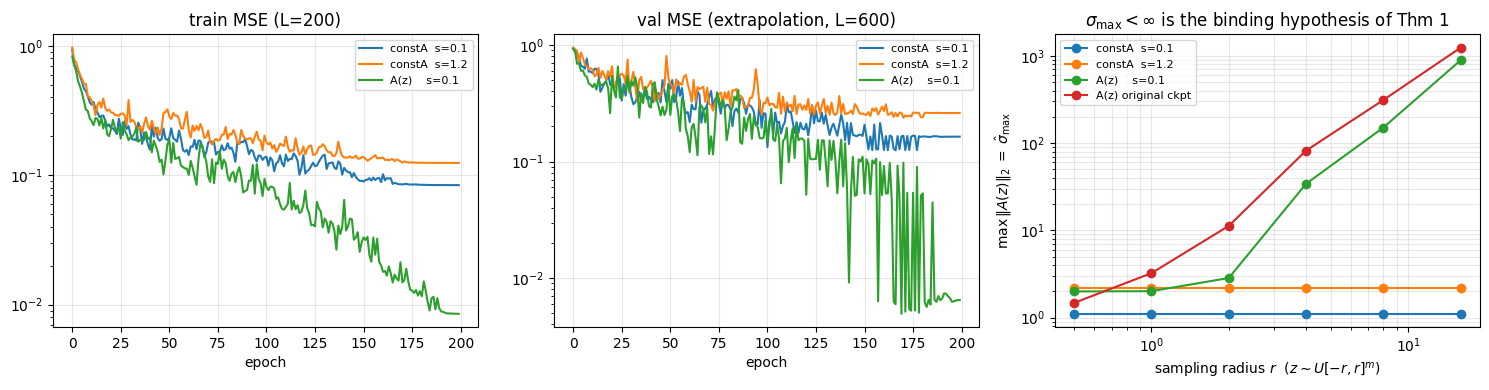

foundation.tex Thm 1:   R_ball = (sigma_max / sigma_min) * r_in,   r_in = R_g*sqrt(m) = 4.000

  constA  s=0.1          sigma_max=||A||_2= 1.107   lambda_max(sym A)= -0.167 (<= -0.1)   R_ball=   44.28
  constA  s=1.2          sigma_max=||A||_2= 2.195   lambda_max(sym A)= -1.236 (<= -1.2)   R_ball=    7.32
  A(z)    s=0.1          sigma_max = sup_z ||A(z)||_2 = inf  ->  Thm 1 vacuous, NO invariant set
  A(z) original ckpt     sigma_max = sup_z ||A(z)||_2 = inf  ->  Thm 1 vacuous, NO invariant set


In [6]:
def R_ball(mdl):
    """foundation.tex Thm 1 with x0=0, r_in = R_g*sqrt(m):  R = (sigma_max/sigma_min) * r_in.
    sigma_max = ||A||_2. Returns nan when A is state-dependent (sigma_max = inf)."""
    dyn = mdl.dynamics
    if not isinstance(dyn, LatentFTNODEConstA): return float('nan')
    nA = torch.linalg.matrix_norm(dyn.A_const().detach(), 2).item()
    return nA * R_LATENT * np.sqrt(m) / dyn.sigma_min

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name, h in HISTS.items():
    if not h['train']: continue
    axes[0].semilogy(h['train'], label=name)
    axes[1].semilogy(np.maximum(h['val'], 1e-12), label=name)
for ax, t in zip(axes[:2], [f'train MSE (L={L})', f'val MSE (extrapolation, L={L_eval})']):
    ax.set_title(t); ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=.3)

radii = np.array([0.5, 1, 2, 4, 8, 16])
for name, mdl in MODELS.items():
    with torch.no_grad():
        ns = [torch.linalg.matrix_norm(mdl.dynamics.A(((2*torch.rand(256, m) - 1) * r).to(device)), 2).max().item()
              for r in radii]
    axes[2].loglog(radii, ns, 'o-', label=name)
axes[2].set_xlabel(r'sampling radius $r$  ($z\sim U[-r,r]^m$)')
axes[2].set_ylabel(r'$\max\,\|A(z)\|_2 \;=\; \hat\sigma_{\max}$')
axes[2].set_title(r'$\sigma_{\max}<\infty$ is the binding hypothesis of Thm 1')
axes[2].legend(fontsize=8); axes[2].grid(alpha=.3, which='both')
plt.tight_layout(); plt.show()

print('foundation.tex Thm 1:   R_ball = (sigma_max / sigma_min) * r_in,   r_in = R_g*sqrt(m) ='
      f' {R_LATENT*np.sqrt(m):.3f}\n')
for name, mdl in MODELS.items():
    dyn = mdl.dynamics
    if isinstance(dyn, LatentFTNODEConstA):
        A  = dyn.A_const().detach()
        smax = torch.linalg.matrix_norm(A, 2).item()
        lmax = torch.linalg.eigvalsh(.5*(A + A.T)).max().item()   # must be <= -sigma_min
        print(f'  {name:22s} sigma_max=||A||_2={smax:6.3f}   lambda_max(sym A)={lmax:+7.3f} '
              f'(<= -{dyn.sigma_min})   R_ball={R_ball(mdl):8.2f}')
    else:
        print(f'  {name:22s} sigma_max = sup_z ||A(z)||_2 = inf  ->  Thm 1 vacuous, NO invariant set')

## 3. Jacobian machinery (item 2)

$J_\theta$ by `vmap(jacrev(...))`. Two assertions:
1. constant $A$: $J_\theta \overset{!}{=} A\,(I-\partial_zg_\theta)$ — confirms the correction term is gone;
2. state-dependent $A$: autograd $J_\theta$ against central differences.

In [7]:
def _F_single(dyn, z, u):
    return dyn.F(z.unsqueeze(0), u.unsqueeze(0)).squeeze(0)

def jac_F(dyn, Z, U, chunk=512):
    """Exact Jacobian of the latent field.  Z:(N,m) U:(N,) -> (N,m,m)."""
    out = []
    for i in range(0, Z.shape[0], chunk):
        out.append(vmap(jacrev(lambda z, u: _F_single(dyn, z, u), argnums=0))(
            Z[i:i+chunk], U[i:i+chunk]).detach())
    return torch.cat(out)

def jac_g(dyn, Z, U, chunk=512):
    f = lambda z, u: dyn.g(z.unsqueeze(0), u.unsqueeze(0)).squeeze(0)
    out = []
    for i in range(0, Z.shape[0], chunk):
        out.append(vmap(jacrev(f, argnums=0))(Z[i:i+chunk], U[i:i+chunk]).detach())
    return torch.cat(out)

def ky_fan(J, k=2):
    """KF_k = sum of k largest eigenvalues of sym(J)  =  mu_2(J^[k]).  No compound is formed."""
    lam = torch.linalg.eigvalsh(.5 * (J + J.transpose(-1, -2))).flip(-1)
    return lam[..., :k].sum(-1), lam

def spec_k(J, k=2):
    """s_k = max over k-subsets of Re(sum lambda_i)  =  spectral abscissa of J^[k]."""
    ev, _ = torch.sort(torch.linalg.eigvals(J).real, dim=-1, descending=True)
    return ev[..., :k].sum(-1), ev

Zc = ((2*torch.rand(128, m) - 1) * R_LATENT).to(device)
Uc = ((2*torch.rand(128) - 1) * u_range).to(device)

for name, mdl in MODELS.items():
    dyn = mdl.dynamics
    if isinstance(dyn, LatentFTNODEConstA):
        A  = dyn.A_const().detach()
        Jc = torch.einsum('ij,bjk->bik', A,
                          torch.eye(m, device=device).expand(128, m, m) - jac_g(dyn, Zc, Uc))
        err = (jac_F(dyn, Zc, Uc) - Jc).abs().max().item()
        print(f'{name:22s} ||J - A(I - dg/dz)||_inf = {err:.2e}')
        assert err < 1e-4, 'closed-form Jacobian mismatch'

def fd_jac(dyn, z, u, eps=1e-4):
    J = torch.zeros(m, m)
    for j in range(m):
        e = torch.zeros(m, device=device); e[j] = eps
        with torch.no_grad():
            J[:, j] = ((dyn.F((z+e).unsqueeze(0), u.unsqueeze(0)) -
                        dyn.F((z-e).unsqueeze(0), u.unsqueeze(0))).squeeze(0) / (2*eps)).cpu()
    return J

for name, mdl in MODELS.items():
    if isinstance(mdl.dynamics, LatentFTNODE):
        e = (jac_F(mdl.dynamics, Zc[0][None], Uc[0][None])[0].cpu()
             - fd_jac(mdl.dynamics, Zc[0], Uc[0])).abs().max().item()
        print(f'{name:22s} ||J_autograd - J_FD||_inf = {e:.2e}')
        assert e < 1e-2, 'autograd/FD mismatch'
        break
print('\nJacobian machinery OK.')

constA  s=0.1          ||J - A(I - dg/dz)||_inf = 5.96e-07
constA  s=1.2          ||J - A(I - dg/dz)||_inf = 5.96e-07
A(z)    s=0.1          ||J_autograd - J_FD||_inf = 1.63e-03

Jacobian machinery OK.


## 4. Item 2 — the real contraction diagnostic

Three probes. Only the **ball** is a set on which the theorems have a hypothesis.

In [8]:
def eval_sets(mdl, n_roll=N_ROLL, n_box=N_BOX, seed=0):
    with torch.no_grad():
        _, Zr = rollout_y(mdl, Wva, Uva, L_eval, h_dt)
    B, T = Zr.shape[0], Zr.shape[1]
    Zr = Zr.reshape(-1, m); Ur = Uva.view(-1, 1).expand(B, T).reshape(-1)
    g = torch.Generator().manual_seed(seed)
    sub = torch.randperm(Zr.shape[0], generator=g)[:n_roll].to(device)
    sets = {'rollout': (Zr[sub], Ur[sub])}
    Ub = ((2*torch.rand(n_box, generator=g) - 1) * u_range).to(device)
    sets['box'] = (((2*torch.rand(n_box, m, generator=g) - 1) * R_LATENT).to(device), Ub)
    Rb = R_ball(mdl)
    if np.isfinite(Rb):                                   # uniform in the certified invariant ball
        v = torch.randn(n_box, m, generator=g); v = v / v.norm(dim=-1, keepdim=True)
        r = Rb * torch.rand(n_box, 1, generator=g) ** (1.0 / m)
        sets['ball'] = ((v * r).to(device), Ub.clone())
    return sets, Zr.norm(dim=-1).max().item()

RESULTS = {}
print(f'{"model":22s} {"set":8s} {"max lam1(symJ)":>15s} {"max KF2":>10s} {"max s2":>10s} {"mean trJ":>10s}')
print('-' * 84)
for name, mdl in MODELS.items():
    sets, zmax = eval_sets(mdl); R = {}
    for tag, (Z, U) in sets.items():
        J = jac_F(mdl.dynamics, Z, U)
        kf, lam = ky_fan(J, 2); s2, ev = spec_k(J, 2)
        trJ = J.diagonal(dim1=-2, dim2=-1).sum(-1)
        R[tag] = dict(kf=kf.cpu().numpy(), s2=s2.cpu().numpy(), lam=lam.cpu().numpy(),
                      ev=ev.cpu().numpy(), tr=trJ.cpu().numpy())
        print(f'{name if tag=="rollout" else "":22s} {tag:8s} {lam[:,0].max():>15.4f} '
              f'{kf.max():>10.4f} {s2.max():>10.4f} {trJ.mean():>10.4f}')
    R['zmax'], R['R_ball'] = zmax, R_ball(mdl)
    RESULTS[name] = R
    print()
print('plant reference (d=2):  max lam1(symJ) = %+.4f   KF2 = s2 = tr J = %+.4f'
      % (LAM1_PLANT_MAX, -params.delta))

model                  set       max lam1(symJ)    max KF2     max s2   mean trJ
------------------------------------------------------------------------------------
constA  s=0.1          rollout           1.6601     1.2311     0.2986    -2.2906
                       box               1.8517     1.4104     0.4871    -1.7366
                       ball              1.3456     0.8788     0.0542    -2.2432

constA  s=1.2          rollout           1.1271     0.2455    -0.2947    -5.9187
                       box               1.8543     0.9873     0.4227    -5.1255
                       ball              2.0467     1.0774     0.5352    -5.9301

A(z)    s=0.1          rollout           1.5691     1.4695     0.4845    -1.1456
                       box               7.7803     7.7170     2.0222    -1.4789

A(z) original ckpt     rollout           1.5546     1.2116     0.9172    -2.7689
                       box               6.8178     8.6661     3.8939    -4.8284

plant reference (d=2

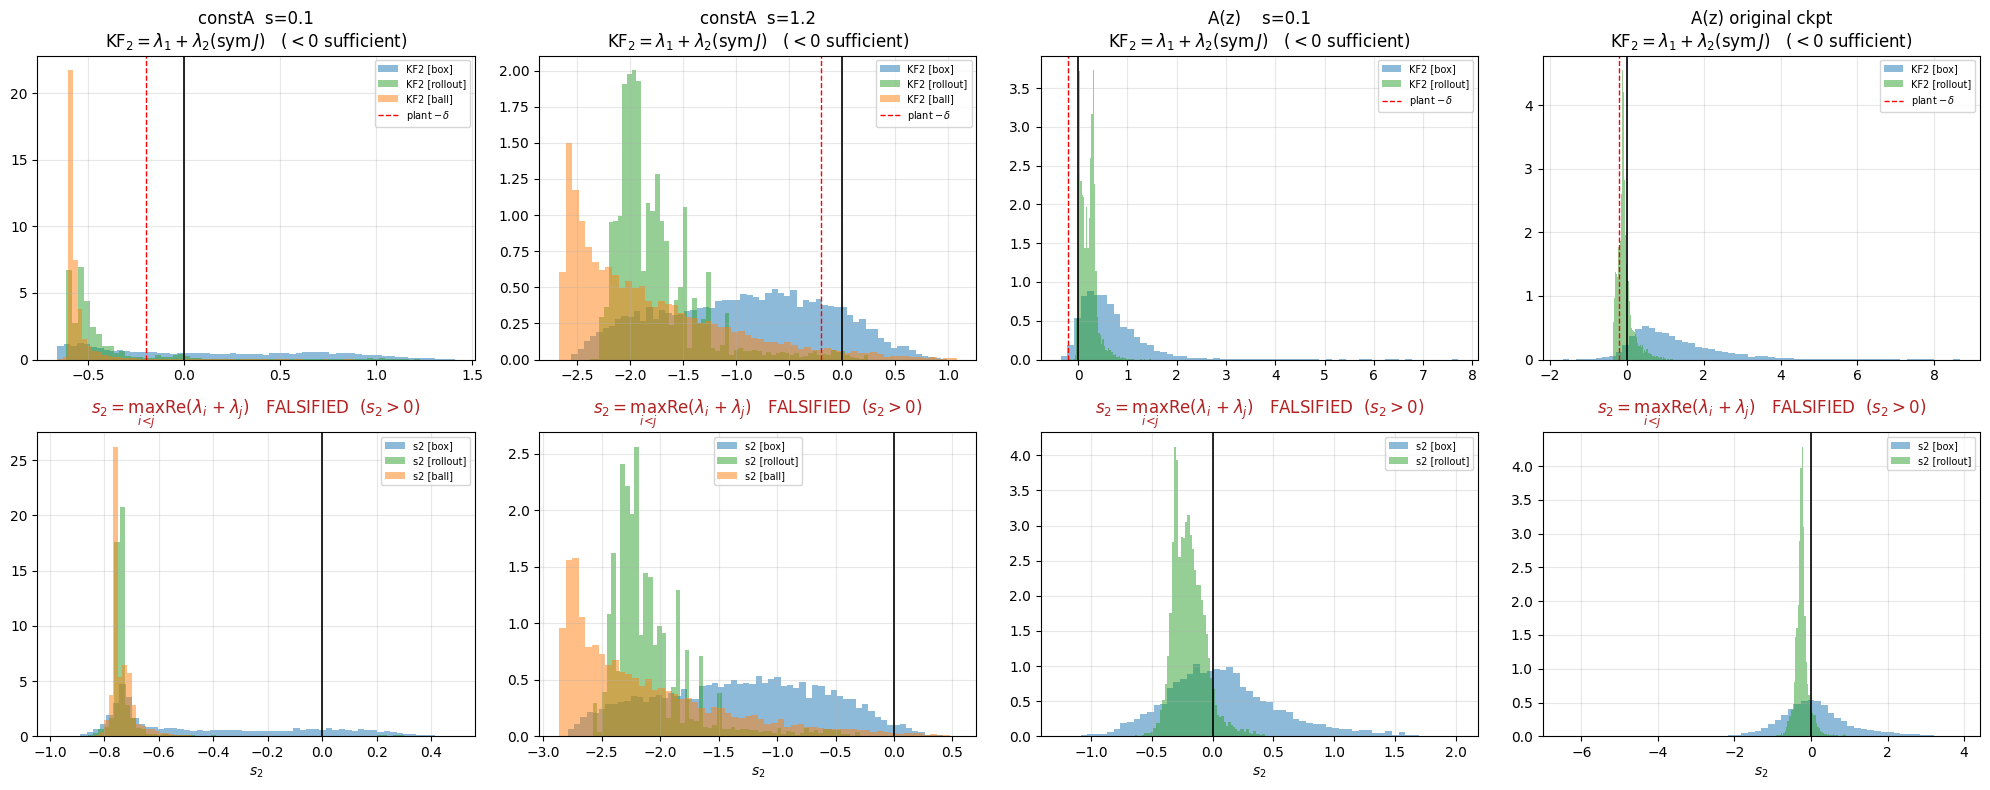

VERDICT (item 2)   -- the theorems live on the INVARIANT set, not the box
constA  s=0.1
   certified invariant ball, R=44.28              s2=+0.0542 KF2=+0.8788  ->  NOT 2-contractive there, under ANY constant P
   rollout states                                 s2=+0.2986 KF2=+1.2311  ->  obstruction present (s2>0)
   box states                                     s2=+0.4871 KF2=+1.4104  ->  obstruction present (s2>0)
   rollout max ||z|| = 3.51   (box corner = 4.00)

constA  s=1.2
   certified invariant ball, R=7.32               s2=+0.5352 KF2=+1.0774  ->  NOT 2-contractive there, under ANY constant P
   rollout states                                 s2=-0.2947 KF2=+0.2455  ->  inconclusive at P=I
   box states                                     s2=+0.4227 KF2=+0.9873  ->  obstruction present (s2>0)
   rollout max ||z|| = 3.59   (box corner = 4.00)

A(z)    s=0.1
   state-dependent A: NO invariant set certified  -> the pointwise signs below carry no theorem
   rollout states        

In [9]:
nm = len(MODELS)
fig, axes = plt.subplots(2, nm, figsize=(5.0*nm, 8), squeeze=False)
for j, (name, R) in enumerate(RESULTS.items()):
    tags = [('box', 'C0'), ('rollout', 'C2')] + ([('ball', 'C1')] if 'ball' in R else [])
    ax = axes[0, j]
    for tag, c in tags:
        ax.hist(R[tag]['kf'], bins=60, density=True, alpha=.5, color=c, label=f'KF2 [{tag}]')
    ax.axvline(0, color='k', lw=1.2)
    ax.axvline(-params.delta, color='r', ls='--', lw=1, label=r'plant $-\delta$')
    ax.set_title(f'{name}\n' + r'$\mathrm{KF}_2=\lambda_1+\lambda_2(\mathrm{sym}\,J)$   ($<0$ sufficient)')
    ax.legend(fontsize=7); ax.grid(alpha=.3)

    ax = axes[1, j]
    for tag, c in tags:
        ax.hist(R[tag]['s2'], bins=60, density=True, alpha=.5, color=c, label=f's2 [{tag}]')
    ax.axvline(0, color='k', lw=1.2)
    bad = max(R[t]['s2'].max() for t, _ in tags)
    ax.set_title(r'$s_2=\max_{i<j}\mathrm{Re}(\lambda_i+\lambda_j)$   '
                 + ('FALSIFIED  ($s_2>0$)' if bad > 0 else 'no obstruction'),
                 color=('firebrick' if bad > 0 else 'darkgreen'))
    ax.set_xlabel(r'$s_2$'); ax.legend(fontsize=7); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print('VERDICT (item 2)   -- the theorems live on the INVARIANT set, not the box\n' + '=' * 94)
for name, R in RESULTS.items():
    print(name)
    if 'ball' in R:
        s2, kf = R['ball']['s2'].max(), R['ball']['kf'].max()
        if   s2 > 0: v = 'NOT 2-contractive there, under ANY constant P'
        elif kf < 0: v = '2-contractive there w.r.t. P=I (sampled; a certificate needs a Lipschitz cover)'
        else:        v = 'inconclusive at P=I; try a weighted P'
        lab = f'certified invariant ball, R={R["R_ball"]:.2f}'
        print(f'   {lab:46s} s2={s2:+.4f} KF2={kf:+.4f}  ->  {v}')
    else:
        print(f'   {"state-dependent A: NO invariant set certified":46s} '
              f'-> the pointwise signs below carry no theorem')
    for tag in ('rollout', 'box'):
        s2, kf = R[tag]['s2'].max(), R[tag]['kf'].max()
        note = ('obstruction present (s2>0)' if s2 > 0
                else ('KF2<0 (Euclidean OK)' if kf < 0 else 'inconclusive at P=I'))
        print(f'   {tag + " states":46s} s2={s2:+.4f} KF2={kf:+.4f}  ->  {note}')
    print(f'   rollout max ||z|| = {R["zmax"]:.2f}   (box corner = {R_LATENT*np.sqrt(m):.2f})\n')

## 5. Item 3 — equilibria, tangential vs transverse spectra, transverse-rate test

Solve $z=g_\theta(z,u)$ on the latent box by multistart Newton (analytic Jacobian $I-\partial_zg$),
then classify. Columns `lam_max(sym Jg)` and `||dg||_2` are the `foundation.tex` quantities from
`thm:hurwitz-sym` and `prop:hierarchy`; `eq:sym-cond` ($\lambda_{\max}(\operatorname{sym}J_g)<1$) is
**expected to fail at the saddle**.

In [10]:
def find_equilibria(mdl, u, n_starts=N_STARTS, R=R_LATENT, seed=0, res_tol=1e-6, dedup=1e-4):
    dyn = mdl.dynamics; ut = torch.tensor([float(u)], device=device)
    def resid(z):
        zt = torch.tensor(z, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad(): r = (zt - dyn.g(zt, ut)).squeeze(0)
        return r.cpu().numpy().astype(np.float64)
    def jac(z):
        zt = torch.tensor(z, dtype=torch.float32, device=device).unsqueeze(0)
        return (np.eye(m) - jac_g(dyn, zt, ut)[0].cpu().numpy()).astype(np.float64)
    rng = np.random.default_rng(seed); sols = []
    for _ in range(n_starts):
        s = scipy_root(resid, rng.uniform(-R, R, size=m), jac=jac, method='hybr', tol=1e-12)
        if not s.success: continue
        z = s.x
        if np.max(np.abs(z)) > 1.001 * R:            continue   # outside the image box of g
        if np.linalg.norm(resid(z)) > res_tol:       continue
        if any(np.linalg.norm(z - t) < dedup for t in sols): continue
        sols.append(z)
    return np.array(sols) if sols else np.zeros((0, m))

def match_plant(spec_c, plant_spec):
    """Greedy pairing of learned eigenvalues to the plant's -> (tangential idx, transverse idx)."""
    used = []
    for lp in plant_spec:
        d = [abs(spec_c[i] - lp) if i not in used else np.inf for i in range(len(spec_c))]
        used.append(int(np.argmin(d)))
    return used, [i for i in range(len(spec_c)) if i not in used]

U_EVAL = 0.0
plant_spec = {round(float(x[0]), 3): np.linalg.eigvals(J_plant(x[0])) for x in equilibria_plant(U_EVAL)}
print(f'plant equilibria at u={U_EVAL}: ' +
      ',  '.join(f'q*={q:+.3f} spec={np.round(s,3)}' for q, s in plant_spec.items()) + '\n')

EQ = {}
for name, mdl in MODELS.items():
    E = find_equilibria(mdl, U_EVAL)
    if len(E) == 0:
        print(f'--- {name} ---   no equilibria found in the box (underfit?)\n'); continue
    Ze  = torch.tensor(E, dtype=torch.float32, device=device)
    Ue  = torch.full((len(E),), U_EVAL, device=device)
    Je  = jac_F(mdl.dynamics, Ze, Ue)
    s2e, _ = spec_k(Je, 2)
    spec = torch.linalg.eigvals(Je).cpu().numpy()
    dg   = jac_g(mdl.dynamics, Ze, Ue)
    idx  = torch.sign(torch.linalg.det(torch.eye(m, device=device) - dg)).cpu().numpy()
    lmax_symJg = torch.linalg.eigvalsh(.5*(dg + dg.transpose(-1,-2))).max(-1).values.cpu().numpy()
    nrm_dg     = torch.linalg.matrix_norm(dg, 2).cpu().numpy()
    with torch.no_grad(): qstar = mdl.decode(Ze).cpu().numpy()
    o = np.argsort(qstar)
    EQ[name] = dict(Z=E[o], q=qstar[o], spec=spec[o], s2=s2e.cpu().numpy()[o], idx=idx[o],
                    lmax=lmax_symJg[o], ndg=nrm_dg[o])

    warn = '' if len(E) == 3 else '   <-- expected 3; underfit, item 3 will be vacuous'
    print(f'--- {name} ---   {len(E)} equilibria,  index sum = {idx.sum():+.0f}  '
          f'{"OK" if abs(idx.sum()-1) < 1e-6 else "!! should be +1"}{warn}')
    print(f'  {"q*":>8s} {"tangential spec":>34s} {"transverse tau":>24s} {"s2":>8s} '
          f'{"lam_max(symJg)":>15s} {"||dg||_2":>9s} {"idx":>4s}')
    for k in o:
        sc = spec[k]
        qn = min(plant_spec, key=lambda p: abs(p - qstar[k]))
        t_i, x_i = match_plant(sc, plant_spec[qn])
        tang = ', '.join(f'{v.real:+.3f}{v.imag:+.3f}j' for v in sc[t_i])
        tran = ', '.join(f'{v.real:+.3f}' for v in sc[x_i])
        print(f'  {qstar[k]:+8.3f} [{tang:>32s}] [{tran:>20s}] {float(s2e[k]):+8.3f} '
              f'{lmax_symJg[k]:>15.3f} {nrm_dg[k]:>9.3f} {idx[k]:+4.0f}')
    print()

plant equilibria at u=0.0: q*=-1.000 spec=[-0.1+1.411j -0.1-1.411j],  q*=+0.000 spec=[ 0.905 -1.105],  q*=+1.000 spec=[-0.1+1.411j -0.1-1.411j]

--- constA  s=0.1 ---   3 equilibria,  index sum = +1  OK
        q*                    tangential spec           transverse tau       s2  lam_max(symJg)  ||dg||_2  idx
    -0.977 [    -0.374+0.063j, -0.374-0.063j] [      -0.765, -0.765]   -0.749           0.424     0.580   +1
    -0.005 [    +0.793+0.000j, -0.570+0.163j] [      -0.570, -0.506]   +0.287           2.740     3.215   -1
    +0.968 [    -0.370+0.180j, -0.370-0.180j] [      -0.948, -0.747]   -0.740           0.287     0.539   +1

--- constA  s=1.2 ---   3 equilibria,  index sum = +1  OK
        q*                    tangential spec           transverse tau       s2  lam_max(symJg)  ||dg||_2  idx
    -0.878 [    -0.845+0.000j, -1.399+0.000j] [      -2.313, -1.558]   -2.244           0.484     0.686   +1
    +0.090 [    +0.794+0.000j, -1.122+0.000j] [      -2.313, -1.497]   -0.328   

ITEM 3 — transverse-rate test at the saddle   (need  tau_j < -lambda_1)
----------------------------------------------------------------------------------------
constA  s=0.1          q*=-0.005  lam1=+0.793 (plant +0.905)  tau=[-0.57  -0.506]  max(lam1+tau)=+0.287  FAIL -> not 2-contractive at the saddle
constA  s=1.2          q*=+0.090  lam1=+0.794 (plant +0.905)  tau=[-2.313 -1.497]  max(lam1+tau)=-0.702  PASS
A(z)    s=0.1          VACUOUS: no equilibrium has Re(lambda) > 0, so the model has not learned a saddle (1 eq. found, expected 3). Train longer before reading this test.
A(z) original ckpt     q*=-0.040  lam1=+0.804 (plant +0.905)  tau=[-0.613 -0.613]  max(lam1+tau)=+0.191  FAIL -> not 2-contractive at the saddle

design rule:  sigma_min  must exceed  lambda_1(saddle) = 0.905


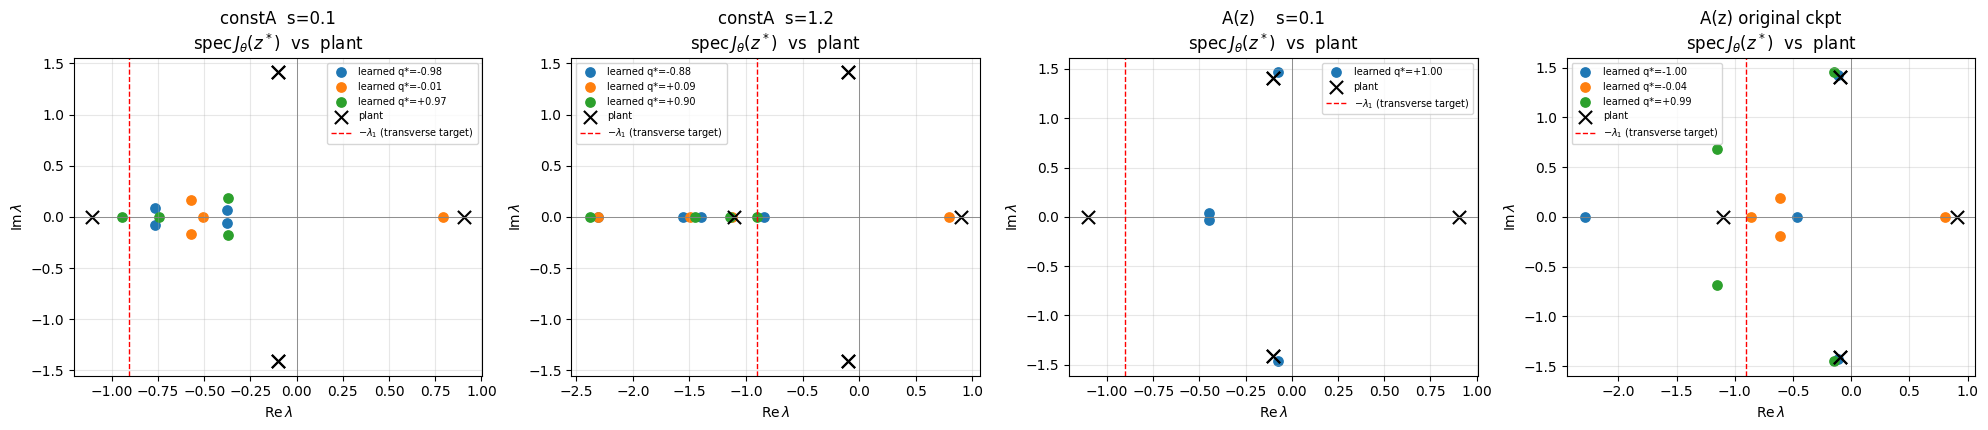

In [11]:
def saddle_of(E):
    """A genuine saddle has an eigenvalue with positive real part."""
    cand = [k for k in range(len(E['q'])) if E['spec'][k].real.max() > 0]
    return cand[int(np.argmin([abs(E['q'][k]) for k in cand]))] if cand else None

print('ITEM 3 — transverse-rate test at the saddle   (need  tau_j < -lambda_1)\n' + '-' * 88)
SADDLE = {}
for name, E in EQ.items():
    k = saddle_of(E)
    if k is None:
        print(f'{name:22s} VACUOUS: no equilibrium has Re(lambda) > 0, so the model has not learned a '
              f'saddle ({len(E["q"])} eq. found, expected 3). Train longer before reading this test.')
        continue
    sc = E['spec'][k]
    t_i, x_i = match_plant(sc, plant_spec[min(plant_spec, key=abs)])
    lam1, taus = max(sc[t_i].real), sc[x_i].real
    worst = lam1 + taus.max(); SADDLE[name] = worst
    print(f'{name:22s} q*={E["q"][k]:+.3f}  lam1={lam1:+.3f} (plant {LAM1_SPEC_SADDLE:+.3f})  '
          f'tau={np.round(taus,3)}  max(lam1+tau)={worst:+.3f}  '
          f'{"PASS" if worst < 0 else "FAIL -> not 2-contractive at the saddle"}')
if EQ and not SADDLE:
    print('\n  All models underfit: no saddle recovered, so item 3 cannot be evaluated.')
    print('  Raise EPOCHS / N_TRAIN (SMOKE=False, or QUICK=False) until 3 equilibria appear.')
print(f'\ndesign rule:  sigma_min  must exceed  lambda_1(saddle) = {LAM1_SPEC_SADDLE:.3f}')

if EQ:
    fig, axes = plt.subplots(1, len(EQ), figsize=(5.0*len(EQ), 4.4), squeeze=False)
    for j, (name, E) in enumerate(EQ.items()):
        ax = axes[0, j]
        for k in range(len(E['q'])):
            ax.scatter(E['spec'][k].real, E['spec'][k].imag, s=45, label=f"learned q*={E['q'][k]:+.2f}")
        first = list(plant_spec)[0]
        for q, s in plant_spec.items():
            ax.scatter(s.real, s.imag, marker='x', s=90, c='k', label='plant' if q == first else None)
        ax.axvline(0, color='gray', lw=.6); ax.axhline(0, color='gray', lw=.6)
        ax.axvline(-LAM1_SPEC_SADDLE, color='r', ls='--', lw=1, label=r'$-\lambda_1$ (transverse target)')
        ax.set_title(f'{name}\n' + r'$\mathrm{spec}\,J_\theta(z^*)$  vs  plant')
        ax.set_xlabel(r'$\mathrm{Re}\,\lambda$'); ax.set_ylabel(r'$\mathrm{Im}\,\lambda$')
        ax.legend(fontsize=7); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 6. Summary

Two numbers should move you:

* $\max s_2$ on the **certified invariant ball**. Positive $\Rightarrow$ the model admits limit cycles or
  positive Lyapunov exponents somewhere in a set it cannot leave, and *no* constant metric $P$ can
  certify otherwise. Then the root set of $z-g_\theta$ is not the whole asymptotic story.
* the **transverse rates** at the learned saddle: they must sit below $-\lambda_1(\text{saddle})=-0.905$.
  This is what $\sigma_{\min}$ controls — the same $\sigma_{\min}$ that sits in the denominator of $R_{\rm ball}$.
  Both arguments push the same way.

Caveats, stated rather than buried:

* sampled $\mathrm{KF}_2<0$ is a **heuristic**, not a certificate. Certification needs the full invariant set
  plus a Lipschitz constant for $z\mapsto\operatorname{sym}J_\theta(z)$ and an $\varepsilon$-cover, $O(\varepsilon^{-m})$.
* $s_2>0$ **is** a certificate of failure, provided the offending state lies in a forward-invariant set.
  Check `zmax` against `R_ball`. For state-dependent $A$ there is no such set and the sign proves nothing.
* $P=I$ is only sufficient. If $s_2<0<\mathrm{KF}_2$, learn a constant $P\succ0$ on the compound space
  ($6\times6$ for $m=4$) via Angeli's alternating LMI. That is item 4, not this notebook.
* $\operatorname{tr}J_\theta$ is not pinned to $-\delta$ for $m>2$; only the tangential block is.
* raising $\sigma_{\min}$ has a fit cost at fixed budget. That trade — accuracy vs certifiability — is the
  thing to measure, and it is what the `val MSE` column is for.


In [12]:
print('s2 / KF2 are taken on the CERTIFIED INVARIANT SET when one exists, else on rollout states.\n')
print(f'{"model":22s} {"val MSE":>10s} {"zmax":>7s} {"R_ball":>9s} {"s2_dom":>9s} {"KF2_dom":>9s} '
      f'{"#eq":>4s} {"idx sum":>8s} {"saddle max(l1+tau)":>19s}')
print('-' * 108)
for name, mdl in MODELS.items():
    R = RESULTS[name]
    val = HISTS[name]['best_val'] if name in HISTS else float('nan')
    if not np.isfinite(val):
        with torch.no_grad():
            yv, _ = rollout_y(mdl, Wva, Uva, L_eval, h_dt); val = ((yv - Yva) ** 2).mean().item()
    dom  = 'ball' if 'ball' in R else 'rollout'
    worst = SADDLE.get(name, float('nan'))
    neq   = len(EQ[name]['q']) if name in EQ else 0
    isum  = EQ[name]['idx'].sum() if name in EQ else float('nan')
    print(f'{name:22s} {val:10.3e} {R["zmax"]:7.2f} {R["R_ball"]:9.2f} {R[dom]["s2"].max():+9.4f} '
          f'{R[dom]["kf"].max():+9.4f} {neq:4d} {isum:+8.0f} {worst:+19.3f}')

print('\nplant: s2 = tr J = %+.3f everywhere (globally 2-contractive);  lambda_1(saddle) = %+.3f'
      % (-params.delta, LAM1_SPEC_SADDLE))
print('R_ball = nan  ->  state-dependent A: foundation.tex Thm 1 vacuous (sigma_max = inf).')

s2 / KF2 are taken on the CERTIFIED INVARIANT SET when one exists, else on rollout states.

model                     val MSE    zmax    R_ball    s2_dom   KF2_dom  #eq  idx sum  saddle max(l1+tau)
------------------------------------------------------------------------------------------------------------
constA  s=0.1           1.250e-01    3.51     44.28   +0.0542   +0.8788    3       +1              +0.287
constA  s=1.2           2.380e-01    3.59      7.32   +0.5352   +1.0774    3       +1              -0.702
A(z)    s=0.1           4.938e-03    3.35       nan   +0.4845   +1.4695    1       +1                +nan
A(z) original ckpt      6.109e-03    3.00       nan   +0.9172   +1.2116    3       +1              +0.191

plant: s2 = tr J = -0.200 everywhere (globally 2-contractive);  lambda_1(saddle) = +0.905
R_ball = nan  ->  state-dependent A: foundation.tex Thm 1 vacuous (sigma_max = inf).
